In [1]:
from utils.loader import load_json_folder, out_dir, load_folktale_csv
from models.folktale import AnnotatedFolktale
from models.event import MIN_EVENTS
from utils.visualization import plot_genre_distribution, plot_nation_counts


In [2]:
df = load_folktale_csv()

df.describe()

,source,nation,title,text
count,2938,2932,2938,2938
unique,2938,57,2895,2935
top,https://fairytalez.com/momotaro/,north_american_native,The Three Dogs,Two Weeoombeen brothers went out hunting. One ...
freq,1,370,3,2


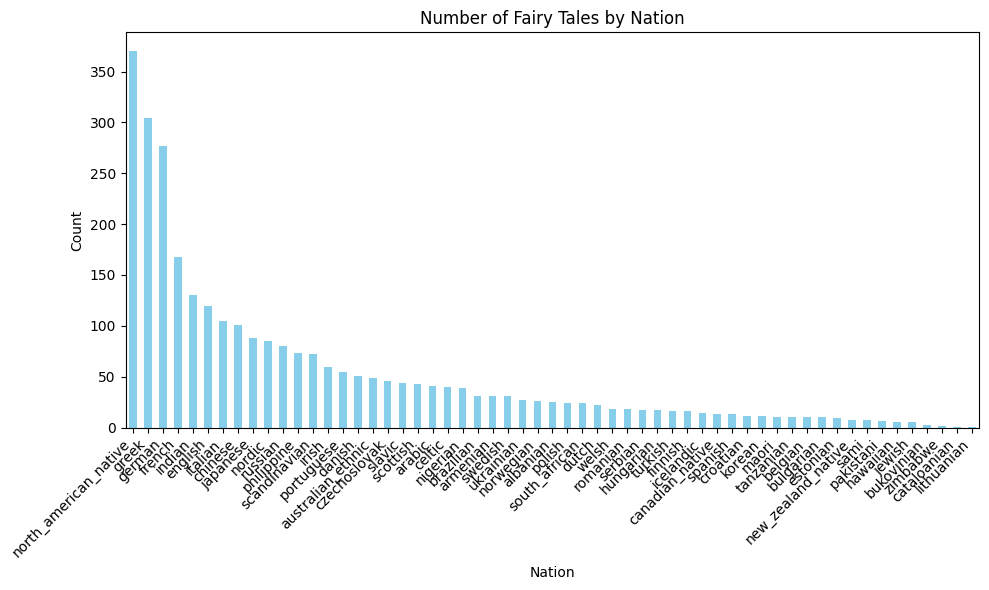

<bound method IndexOpsMixin.value_counts of 0                    japanese
1                     serbian
2                      german
3                      french
4       north_american_native
                ...          
2933        australian_ethnic
2934                 scottish
2935                  italian
2936                norwegian
2937                  finnish
Name: nation, Length: 2938, dtype: str>


In [6]:
nation = df["nation"]
plot_nation_counts(nation)

print(nation.value_counts)


In [4]:
folktales_json = load_json_folder(out_dir)
folktales = [AnnotatedFolktale(**folktale_json) for folktale_json in folktales_json.values()]


'4_the_peace_with_the_snakes' has too few events (0, minimum required: 3)
'767_tawhaki' has too few events (1, minimum required: 3)
'780_the_old_dog' has too few events (1, minimum required: 3)
'785_jack_and_the_beanstalk' has too few events (0, minimum required: 3)
'809_the_king_and_the_ju_ju_tree' has too few events (1, minimum required: 3)
'810_the_peacock_and_juno' has too few events (0, minimum required: 3)
'816_weedah_the_mocking_bird' has too few events (0, minimum required: 3)
'818_the_lion_and_the_boar' has too few events (1, minimum required: 3)
'821_little_tuk' has too few events (0, minimum required: 3)
'823_the_goldbearded_man' has too few events (1, minimum required: 3)
'827_holiday_adventures' has too few events (1, minimum required: 3)
'840_the_fox_and_the_mosquitos' has too few events (3, minimum required: 3)
'8_the_sacred_milk_of_koumongoe' has too few events (1, minimum required: 3)
'9_gobborn_seer' has too few events (1, minimum required: 3)
Average number of events

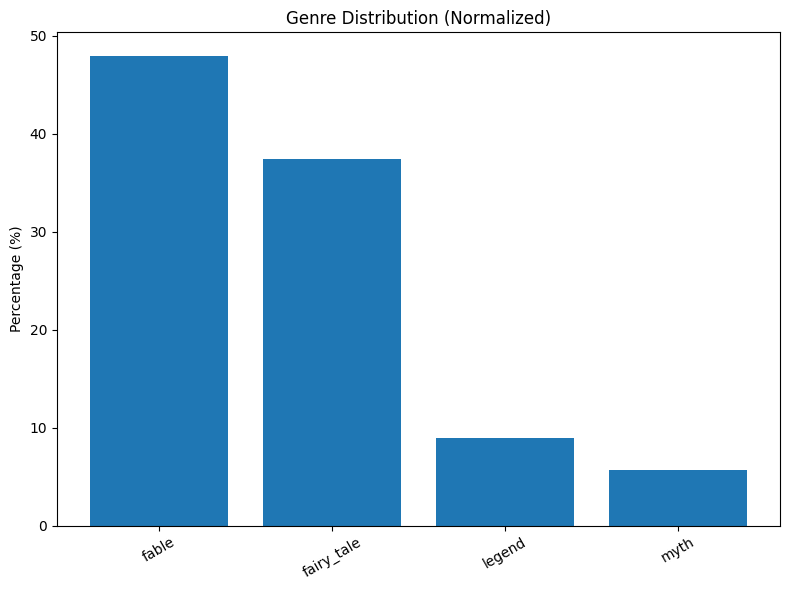

In [5]:
valid_foktales: list[AnnotatedFolktale] = []
for filename, folktale in zip(folktales_json.keys(), folktales):
	n_events = len(folktale.events)
	if n_events <= MIN_EVENTS:
		print(f"'{filename}' has too few events ({n_events}, minimum required: {MIN_EVENTS})")
	else:
		valid_foktales.append(folktale)

average_eventes = sum(len(folktale.events) for folktale in valid_foktales) / len(valid_foktales)
print(f"Average number of events per folktale: {average_eventes}.")

plot_genre_distribution(folktales)
